# Smartphone Usage and Addiction Analysis
### Dataset: 7,500 survey records | 16 columns
**Workflow:** Imports -> Data Loading -> Data Cleaning -> EDA -> Key Questions -> Findings & Conclusion

---
> This notebook is written to be **educational** - every step includes the reasoning behind it,
> not just the code. Read the markdown cells carefully.


## 1. Imports

**Why we import these specific libraries:**
- `pandas` - our main tool for loading, inspecting, and transforming tabular data
- `matplotlib.pyplot` - the foundation of Python plotting; most other libraries build on top of it
- `seaborn` - built on matplotlib, but gives us nicer-looking statistical plots with less code
- `warnings` - we suppress harmless deprecation warnings so the notebook output stays clean

We also set a global plot style and DPI here so every chart in the notebook looks consistent.
You don't want to re-set styles in every cell.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set a consistent visual style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Data Loading & Initial Inspection

Before cleaning or analyzing anything, we first need to **understand the shape and structure** of the data.
This is called an initial inspection, and it answers:
- How many rows and columns do we have?
- What are the column names and their data types?
- Are there any obvious issues right away?

Think of it as reading the table of contents before diving into a book.


In [2]:
df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("Column names and data types:")
print(df.dtypes)


Shape: 7,500 rows x 16 columns

Column names and data types:
transaction_id                 str
user_id                        str
age                          int64
gender                         str
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                   str
academic_work_impact           str
addiction_level                str
addicted_label               int64
dtype: object


In [3]:
# .head() shows the first 5 rows - confirms the data loaded correctly
# and gives you a feel for what values look like in practice
df.head()


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [4]:
# .describe() gives summary statistics for all numeric columns:
# count, mean, std, min, max, and quartiles (25%, 50%, 75%)
# This helps you spot outliers, impossible values, or skewed distributions early
df.describe()


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


## 3. Data Cleaning

Data cleaning is the process of fixing or removing anything in the dataset that would
make your analysis inaccurate or misleading. Real-world data is almost never perfectly clean.

**The general checklist:**
1. Drop columns that carry no analytical value
2. Check for and handle missing (null) values
3. Check for duplicate rows
4. Validate that values are within realistic/logical ranges
5. Fix data types where needed (e.g., strings that should be ordered categories)

**Why does order matter?**
You clean *before* you analyze. If you run EDA on dirty data, your charts and statistics
will reflect the noise, not the real patterns.


### Step 1: Drop ID Columns

`transaction_id` and `user_id` are identifiers - they exist to uniquely tag each row,
but they hold zero information about smartphone behavior.

Including them in analysis would be like counting a student's ID number as a grade.
We drop them immediately.


In [5]:
df.drop(columns=['transaction_id', 'user_id'], inplace=True)
print(f"Shape after dropping ID columns: {df.shape}")
print("Remaining columns:", df.columns.tolist())


Shape after dropping ID columns: (7500, 14)
Remaining columns: ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


### Step 2: Handle Missing Values

Missing values (nulls) are dangerous - most functions will either error out or silently
ignore null rows, leading to misleading results.

**Strategy depends on volume and context:**
- If only 1-2% of rows have nulls, dropping is usually fine
- If 10-15%, dropping wastes too much data - better to fill with a meaningful placeholder
- Never fill numeric columns like age or hours with 0 unless 0 is actually meaningful

Here, `addiction_level` has 819 nulls (~11% of 7,500 rows). We fill with `"Unknown"`
to keep those rows for other analyses while being honest that we don't have a label.


In [6]:
print("Null counts per column:")
print(df.isnull().sum())
print()

# Fill missing addiction_level with 'Unknown'
df['addiction_level'] = df['addiction_level'].fillna('Unknown')

print("Null counts after filling:")
print(df.isnull().sum())
print()
print(f"'Unknown' entries in addiction_level: {(df['addiction_level'] == 'Unknown').sum()}")


Null counts per column:
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

Null counts after filling:
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64

'Unknown' entries in addiction_level: 819


### Step 3: Check for Duplicate Rows

A duplicate row means the same person's data was recorded twice.
This inflates your counts and skews distributions - especially in bar charts and averages.

If duplicates exist, we drop them keeping only the first occurrence.


In [7]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found. Dataset is clean.")


Duplicate rows: 0
No duplicates found. Dataset is clean.


### Step 4: Validate Numeric Ranges

This is a **logic check** - even if a value isn't null, it might be impossible.
For example, a person can't have 30 hours of screen time in a day, or -2 hours of sleep.

We check each hours-related column to make sure values are within realistic bounds.


In [8]:
hour_cols = ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
             'work_study_hours', 'sleep_hours', 'weekend_screen_time']

print("=== Range Check for Hours Columns ===")
for col in hour_cols:
    print(f"  {col:<30} min={df[col].min():.1f}  max={df[col].max():.1f}")

print()
print("Age range:", df['age'].min(), "to", df['age'].max())
print("All values are within realistic bounds. No range issues found.")


=== Range Check for Hours Columns ===
  daily_screen_time_hours        min=3.0  max=12.0
  social_media_hours             min=0.5  max=6.0
  gaming_hours                   min=0.0  max=4.0


  work_study_hours               min=0.5  max=6.0
  sleep_hours                    min=4.5  max=9.0
  weekend_screen_time            min=3.6  max=14.9

Age range: 18 to 35
All values are within realistic bounds. No range issues found.


### Step 5: Create Ordered Categories for Ordinal Columns

`stress_level` (Low/Medium/High) and `addiction_level` (Mild/Moderate/Severe/Unknown)
are **ordinal** - they have a meaningful order, not just labels.

If we leave them as plain strings, pandas treats them as unordered, and plots will
sort them alphabetically (High, Low, Medium) instead of logically (Low, Medium, High).

We also add a numeric mapping for correlation analysis later - you can't correlate
a string with a number, so we encode the order as integers.


In [9]:
# Define logical order for stress
stress_order = ['Low', 'Medium', 'High']
df['stress_level'] = pd.Categorical(df['stress_level'], categories=stress_order, ordered=True)

# Define logical order for addiction (Unknown last)
addiction_order = ['Mild', 'Moderate', 'Severe', 'Unknown']
df['addiction_level'] = pd.Categorical(df['addiction_level'], categories=addiction_order, ordered=True)

# Numeric encodings for correlation analysis
df['stress_num'] = df['stress_level'].map({'Low': 1, 'Medium': 2, 'High': 3})
df['addiction_num'] = df['addiction_level'].map({'Mild': 1, 'Moderate': 2, 'Severe': 3, 'Unknown': 0})

print("Categorical ordering applied.")
print("Stress levels:", df['stress_level'].cat.categories.tolist())
print("Addiction levels:", df['addiction_level'].cat.categories.tolist())


Categorical ordering applied.
Stress levels: ['Low', 'Medium', 'High']
Addiction levels: ['Mild', 'Moderate', 'Severe', 'Unknown']


### Cleaning Summary

| Check | Result |
|---|---|
| ID columns dropped | Yes (transaction_id, user_id) |
| Null values | 819 in addiction_level -> filled with 'Unknown' |
| Duplicates | None found |
| Range validation | All numeric values within realistic bounds |
| Ordinal encoding | stress_level and addiction_level properly ordered |

**The dataset is now clean and ready for analysis.**


## 4. Exploratory Data Analysis (EDA)

EDA is about **understanding the data before asking specific questions**.
You look at distributions, spot patterns, and identify anything unusual.

Think of it as surveying a room before you start searching for something specific.
Good EDA prevents you from being surprised later when your specific analysis
produces unexpected results.

**We will cover:**
- Distributions of numeric columns
- Counts of categorical columns
- Correlation between numeric variables


### 4.1 Distribution of Numeric Variables

A histogram shows you how values are spread. You're looking for:
- Is the distribution symmetric (normal) or skewed?
- Are there outliers (long tails)?
- Is there a clear center or is it spread out?

This matters because skewed data and outliers affect the reliability of averages.


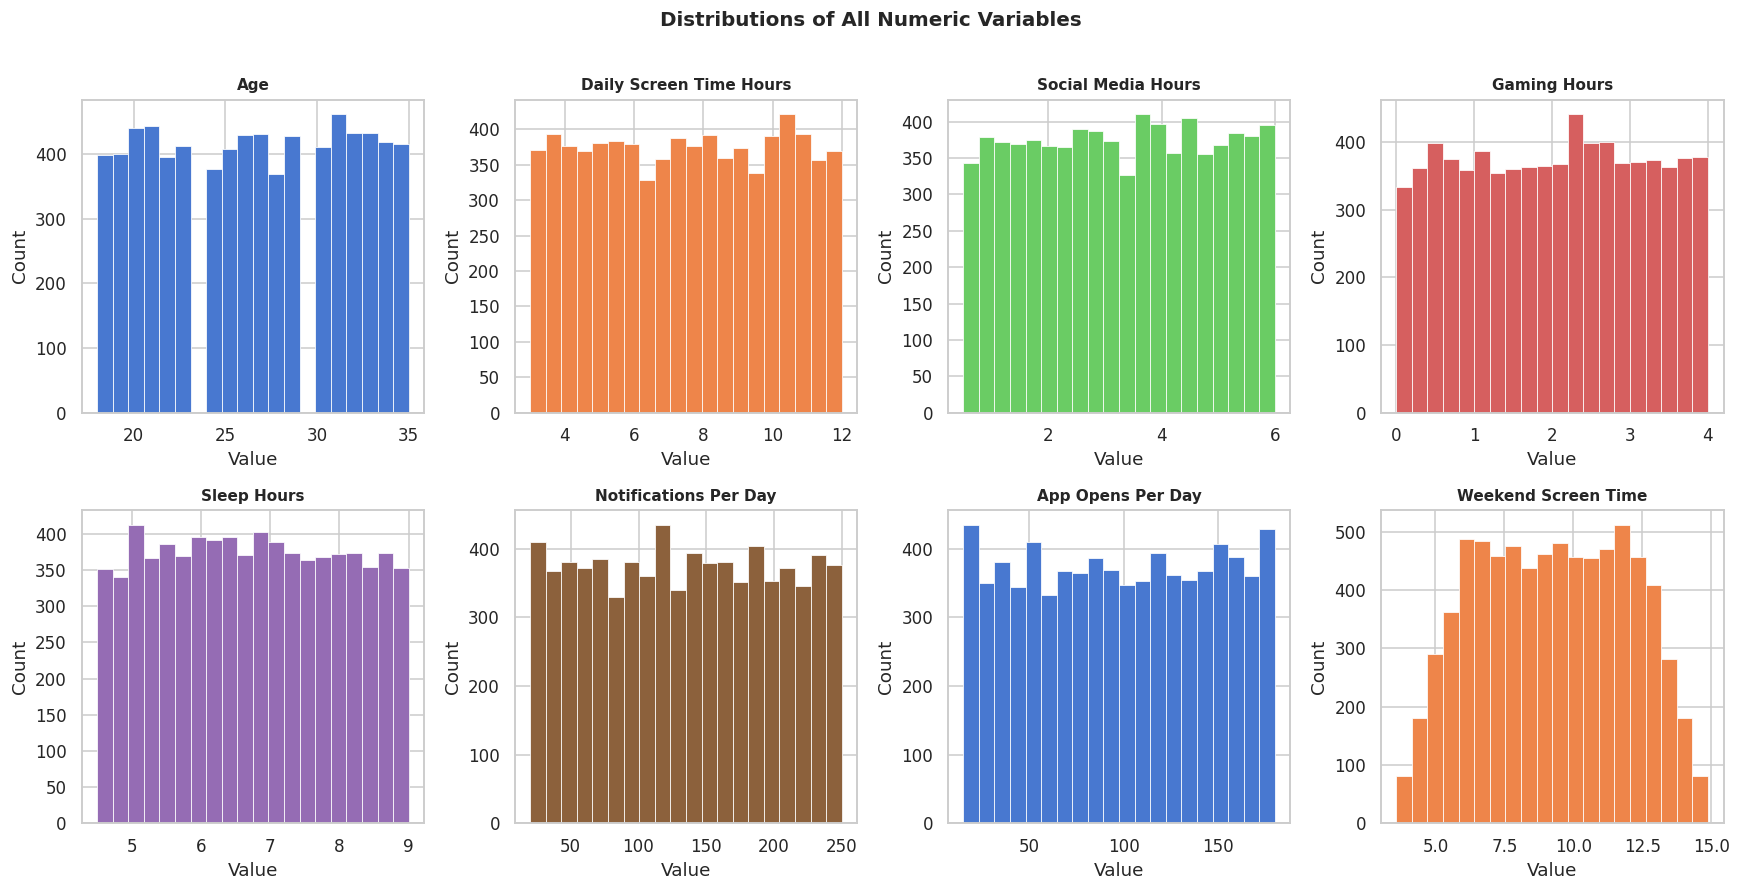

In [10]:
numeric_cols = ['age', 'daily_screen_time_hours', 'social_media_hours',
                'gaming_hours', 'sleep_hours', 'notifications_per_day',
                'app_opens_per_day', 'weekend_screen_time']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color=sns.color_palette('muted')[i % 6],
                 edgecolor='white', linewidth=0.5)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distributions of All Numeric Variables', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_numeric_distributions.png', bbox_inches='tight')
plt.show()


### 4.2 Counts of Categorical Variables

For categorical columns, we use bar charts instead of histograms.
We want to know: is the data balanced across categories, or is one category dominant?

**Why this matters:** If 90% of respondents are Male, any gender-based comparison
becomes unreliable because of the imbalance.


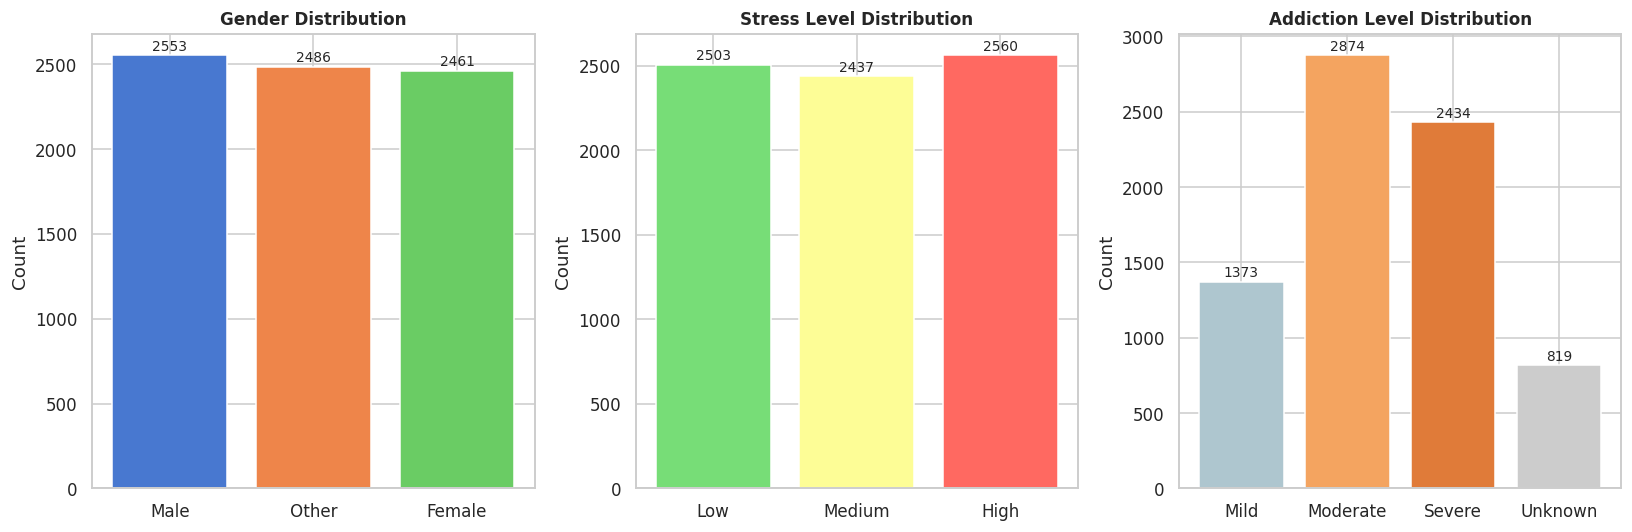

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gender
gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values,
            color=sns.color_palette('muted', 3), edgecolor='white')
axes[0].set_title('Gender Distribution', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(zip(gender_counts.index, gender_counts.values)):
    axes[0].text(i, val + 30, str(val), ha='center', fontsize=9)

# Stress Level
stress_counts = df['stress_level'].value_counts()[stress_order]
axes[1].bar(stress_counts.index, stress_counts.values,
            color=['#77dd77','#fdfd96','#ff6961'], edgecolor='white')
axes[1].set_title('Stress Level Distribution', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count')
for i, val in enumerate(stress_counts.values):
    axes[1].text(i, val + 30, str(val), ha='center', fontsize=9)

# Addiction Level
add_counts = df['addiction_level'].value_counts()[addiction_order]
axes[2].bar(add_counts.index, add_counts.values,
            color=['#aec6cf','#f4a460','#e07b39','#cccccc'], edgecolor='white')
axes[2].set_title('Addiction Level Distribution', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Count')
for i, val in enumerate(add_counts.values):
    axes[2].text(i, val + 30, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_categorical_counts.png', bbox_inches='tight')
plt.show()


### 4.3 Correlation Heatmap

A correlation heatmap shows the relationship between every pair of numeric variables at once.

**Reading it:**
- Values range from -1 to +1
- +1 = perfect positive relationship (both go up together)
- -1 = perfect negative relationship (one goes up, other goes down)
- 0 = no relationship

**Why run this before the key questions?**
It tells you in advance which relationships are worth investigating and which are not.
If screen time and sleep have a correlation close to 0, you already know Q2 might not
show a strong pattern - and that's a valid finding too.


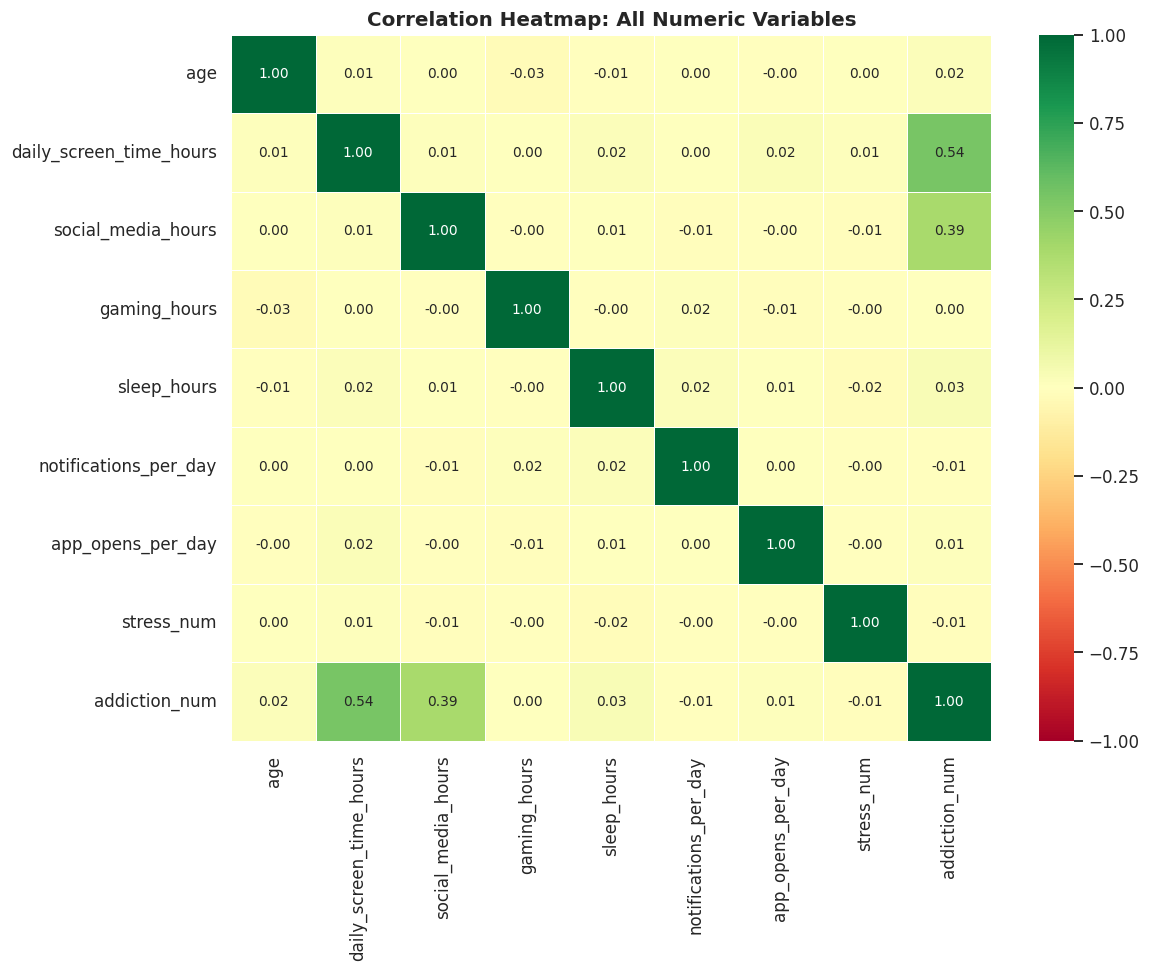

Key correlations to note:
stress_num                -0.018851
age                       -0.007462
gaming_hours              -0.002874
app_opens_per_day          0.005692
social_media_hours         0.005947
notifications_per_day      0.016273
daily_screen_time_hours    0.019343
addiction_num              0.032662
sleep_hours                1.000000
Name: sleep_hours, dtype: float64


In [12]:
corr_cols = ['age', 'daily_screen_time_hours', 'social_media_hours',
             'gaming_hours', 'sleep_hours', 'notifications_per_day',
             'app_opens_per_day', 'stress_num', 'addiction_num']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(i):
        mask.iloc[i, j] = True  # Hide lower triangle for cleanliness

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Correlation Heatmap: All Numeric Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key correlations to note:")
print(corr_matrix['sleep_hours'].sort_values())


## 5. Key Questions

Now we move from general exploration to **targeted analysis**.
Each question has a specific visualization that best communicates the answer.

Choosing the right chart type is as important as the analysis itself:
- Use histograms for distributions
- Use scatter plots for relationships between two continuous variables
- Use box plots for comparing distributions across categories
- Use count/bar plots for categorical comparisons


### Q1: What is the most common range of Daily Screen Time?

**Chart type: Histogram**
A histogram is the correct choice here because `daily_screen_time_hours` is a
continuous numeric variable and we want to see how values are distributed across ranges.

**How to read it:** The tallest bar represents the most common range.
The bin width determines how wide each range is - too few bins hides detail,
too many makes it noisy. 15 bins is usually a good starting point.


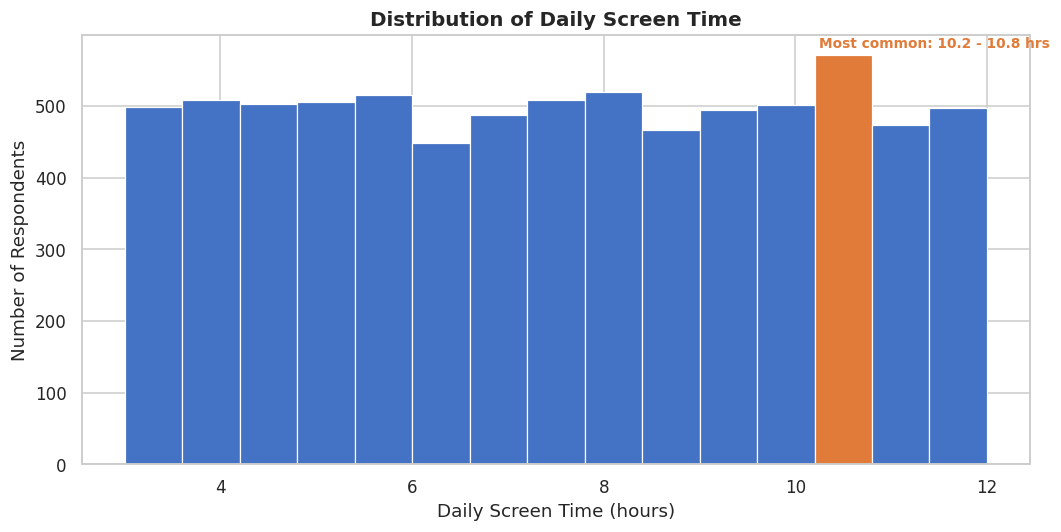

Most common screen time range: 10.2 - 10.8 hrs
Number of respondents in this range: 571
That is 7.6% of all respondents


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(df['daily_screen_time_hours'], bins=15,
                            color='#4472C4', edgecolor='white', linewidth=0.8)

# Highlight the tallest bar
peak_idx = n.argmax()
patches[peak_idx].set_facecolor('#e07b39')
peak_range = f"{bins[peak_idx]:.1f} - {bins[peak_idx+1]:.1f} hrs"

ax.set_title('Distribution of Daily Screen Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Daily Screen Time (hours)')
ax.set_ylabel('Number of Respondents')
ax.text(bins[peak_idx] + 0.05, n[peak_idx] + 10,
        f'Most common: {peak_range}', fontsize=9, color='#e07b39', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Most common screen time range: {peak_range}")
print(f"Number of respondents in this range: {int(n[peak_idx])}")
print(f"That is {n[peak_idx]/len(df)*100:.1f}% of all respondents")


### Q2: Does more notifications and screen time lead to less sleep and more stress?

**Chart type: Scatter plots + Box plot**

This question asks about *relationships* between continuous variables, which is
what scatter plots are built for. We also use a box plot to show how sleep
distribution shifts across stress levels.

**Before plotting:** We already ran the correlation heatmap in EDA.
Check those values - they tell you whether to expect a strong or weak relationship
before you even see the chart. This is good data science practice: form a hypothesis
from the correlation, then visualize to confirm or challenge it.


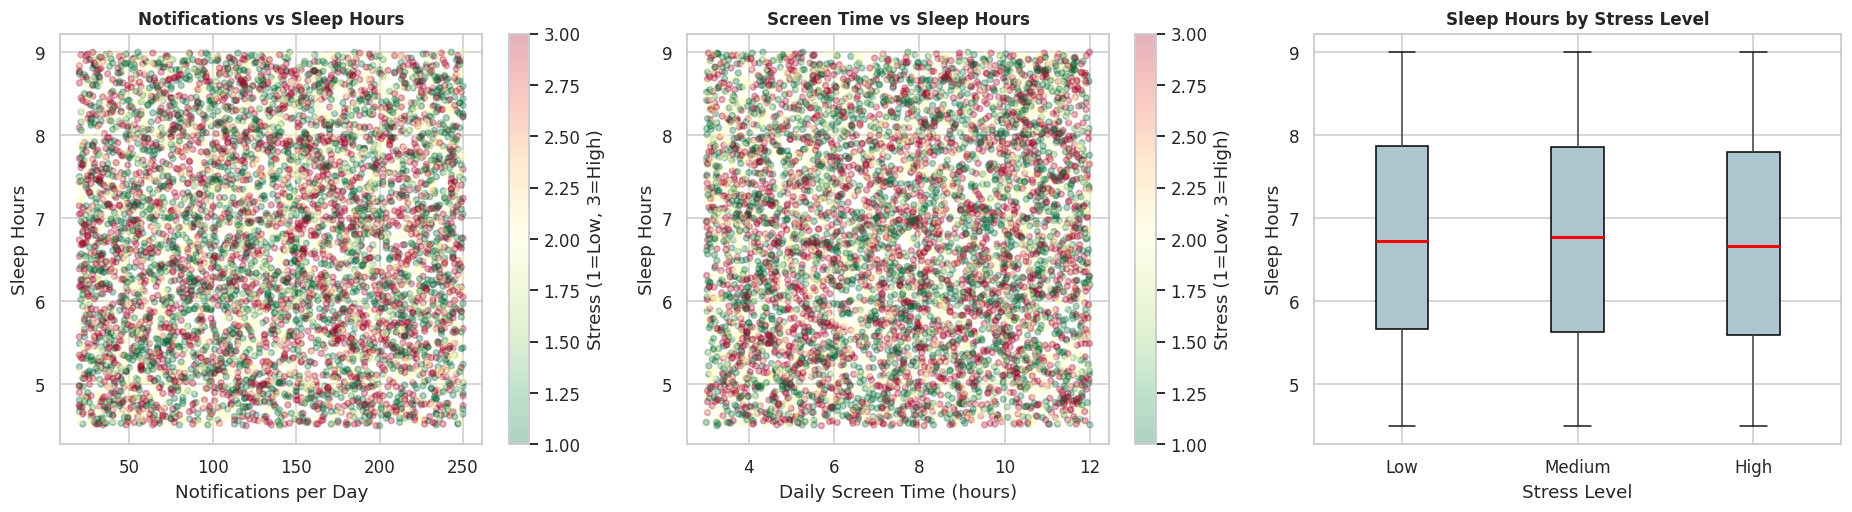

Correlation with sleep_hours:
  notifications_per_day:    0.016
  daily_screen_time_hours:  0.019

Mean sleep hours by stress level:
stress_level
Low       6.76
Medium    6.76
High      6.70
Name: sleep_hours, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

palette = {'Low': '#77dd77', 'Medium': '#fdfd96', 'High': '#ff6961'}

# Scatter 1: Notifications vs Sleep, colored by stress
sc1 = axes[0].scatter(df['notifications_per_day'], df['sleep_hours'],
                       c=df['stress_num'], cmap='RdYlGn_r', alpha=0.3, s=15)
axes[0].set_title('Notifications vs Sleep Hours', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Notifications per Day')
axes[0].set_ylabel('Sleep Hours')
plt.colorbar(sc1, ax=axes[0], label='Stress (1=Low, 3=High)')

# Scatter 2: Screen Time vs Sleep, colored by stress
sc2 = axes[1].scatter(df['daily_screen_time_hours'], df['sleep_hours'],
                       c=df['stress_num'], cmap='RdYlGn_r', alpha=0.3, s=15)
axes[1].set_title('Screen Time vs Sleep Hours', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Daily Screen Time (hours)')
axes[1].set_ylabel('Sleep Hours')
plt.colorbar(sc2, ax=axes[1], label='Stress (1=Low, 3=High)')

# Box plot: Sleep hours by stress level
df.boxplot(column='sleep_hours', by='stress_level', ax=axes[2],
           notch=False, patch_artist=True,
           boxprops=dict(facecolor='#aec6cf'),
           medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Sleep Hours by Stress Level', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Stress Level')
axes[2].set_ylabel('Sleep Hours')
plt.suptitle('')

plt.tight_layout()
plt.savefig('q2_notifications_sleep_stress.png', bbox_inches='tight')
plt.show()

# Print the actual correlations for precision
print("Correlation with sleep_hours:")
print(f"  notifications_per_day:    {df['notifications_per_day'].corr(df['sleep_hours']):.3f}")
print(f"  daily_screen_time_hours:  {df['daily_screen_time_hours'].corr(df['sleep_hours']):.3f}")
print()
print("Mean sleep hours by stress level:")
print(df.groupby('stress_level', observed=True)['sleep_hours'].mean().round(2))


### Q3: Do males and females show different addiction levels or primary usage types?

**Chart type: Grouped count plots**

When comparing a categorical variable (gender) against another categorical variable
(addiction level or usage type), a grouped bar chart is the right tool.
It lets you see both the absolute counts and the relative differences between groups.

**New column:** We need to create a `primary_usage` column that labels each person's
dominant app type by comparing their `gaming_hours` vs `social_media_hours`.
This is called **feature engineering** - creating new variables from existing ones
to answer a question the raw data can't directly answer.


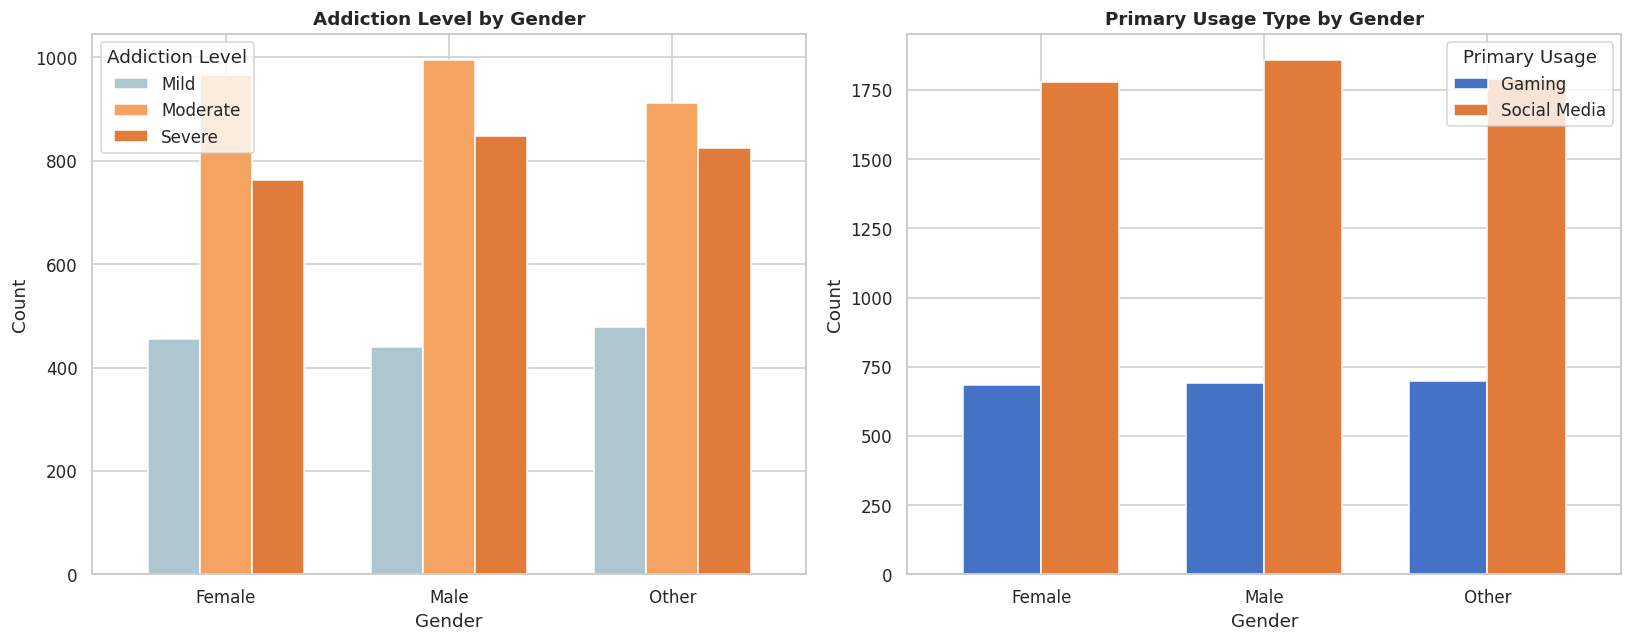

=== Addiction Level % by Gender ===
addiction_level  Mild  Moderate  Severe
gender                                 
Female           20.8      44.3    34.9
Male             19.3      43.6    37.1
Other            21.6      41.2    37.2


In [15]:
# Feature engineering: determine primary usage type per row
df['primary_usage'] = df.apply(
    lambda row: 'Gaming' if row['gaming_hours'] >= row['social_media_hours'] else 'Social Media',
    axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Gender vs Addiction Level
# We exclude 'Unknown' for cleaner comparison
df_known = df[df['addiction_level'] != 'Unknown']
addiction_gender = df_known.groupby(['gender', 'addiction_level'], observed=True).size().unstack()
addiction_gender.plot(kind='bar', ax=axes[0], edgecolor='white',
                      color=['#aec6cf','#f4a460','#e07b39'], width=0.7)
axes[0].set_title('Addiction Level by Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].legend(title='Addiction Level')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Gender vs Primary Usage
usage_gender = df.groupby(['gender', 'primary_usage']).size().unstack()
usage_gender.plot(kind='bar', ax=axes[1], edgecolor='white',
                  color=['#4472C4','#e07b39'], width=0.7)
axes[1].set_title('Primary Usage Type by Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].legend(title='Primary Usage')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('q3_gender_addiction_usage.png', bbox_inches='tight')
plt.show()

print("=== Addiction Level % by Gender ===")
pct = df_known.groupby(['gender','addiction_level'], observed=True).size().unstack()
print((pct.div(pct.sum(axis=1), axis=0) * 100).round(1))


### Q4: Is there a specific Social Media usage hour count that leads to less than 6 hours of sleep?

**Chart type: Box plot + Histogram by group**

We create a new binary column `low_sleep` (True if sleep_hours < 6).
This converts the question into a comparison between two groups: low sleepers vs normal sleepers.

A box plot of `social_media_hours` for each group is the cleanest way to see whether
the distributions differ. If low sleepers have consistently higher social media hours,
the box for `True` will sit higher than the box for `False`.

**The threshold of 6 hours** comes from public health guidelines - below 6 hours
is clinically considered sleep deprivation.


Low sleep respondents (<6hrs): 2474 (33.0%)
Normal sleep respondents:      5026 (67.0%)



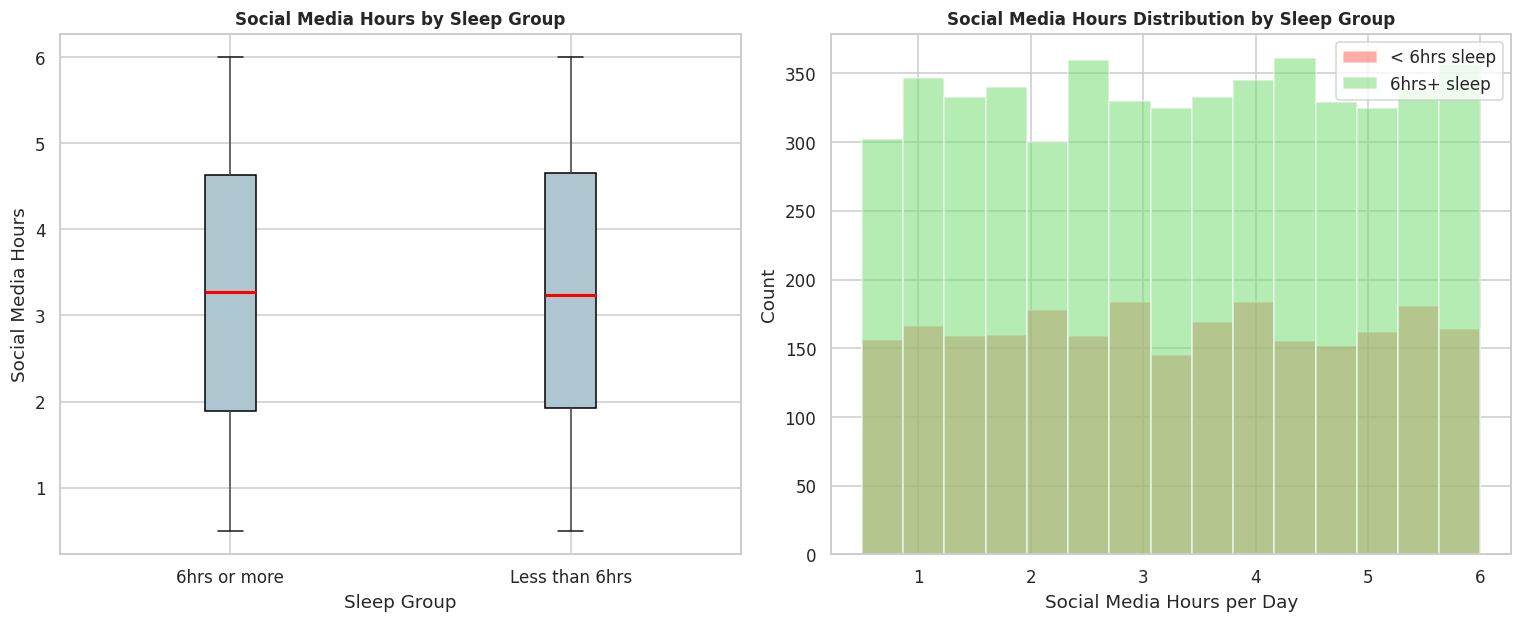

Mean social media hours by sleep group:
                 count  mean   std  min   25%   50%   75%  max
sleep_group                                                   
6hrs or more    5026.0  3.28  1.59  0.5  1.89  3.27  4.63  6.0
Less than 6hrs  2474.0  3.27  1.58  0.5  1.93  3.24  4.66  6.0


In [16]:
# Create low_sleep flag
df['low_sleep'] = df['sleep_hours'] < 6
df['sleep_group'] = df['low_sleep'].map({True: 'Less than 6hrs', False: '6hrs or more'})

print(f"Low sleep respondents (<6hrs): {df['low_sleep'].sum()} ({df['low_sleep'].mean()*100:.1f}%)")
print(f"Normal sleep respondents:      {(~df['low_sleep']).sum()} ({(~df['low_sleep']).mean()*100:.1f}%)")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
df.boxplot(column='social_media_hours', by='sleep_group', ax=axes[0],
           patch_artist=True, notch=False,
           boxprops=dict(facecolor='#aec6cf'),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[0].set_title('Social Media Hours by Sleep Group', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Sleep Group')
axes[0].set_ylabel('Social Media Hours')
plt.suptitle('')

# Overlapping histogram to show full distributions
for group, color, label in [('Less than 6hrs','#ff6961','< 6hrs sleep'),
                              ('6hrs or more','#77dd77','6hrs+ sleep')]:
    subset = df[df['sleep_group'] == group]['social_media_hours']
    axes[1].hist(subset, bins=15, alpha=0.55, color=color, edgecolor='white', label=label)

axes[1].set_title('Social Media Hours Distribution by Sleep Group', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Social Media Hours per Day')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('q4_social_media_sleep.png', bbox_inches='tight')
plt.show()

print("Mean social media hours by sleep group:")
print(df.groupby('sleep_group')['social_media_hours'].describe().round(2))


### Q5: As age increases, does smartphone addiction level tend to decrease?

**Chart type: Box plot + Strip/scatter plot with trend**

A box plot of `age` grouped by `addiction_level` (in correct order: Mild -> Moderate -> Severe)
shows whether older respondents cluster in lower addiction levels.

If the hypothesis is true (older = less addicted), the boxes should trend **downward**
as we move from Mild to Severe - meaning severe addiction is concentrated in younger people.

We also add a scatter with a trend line for visual confirmation.

**Note:** We exclude 'Unknown' here since we don't have a label for those respondents.


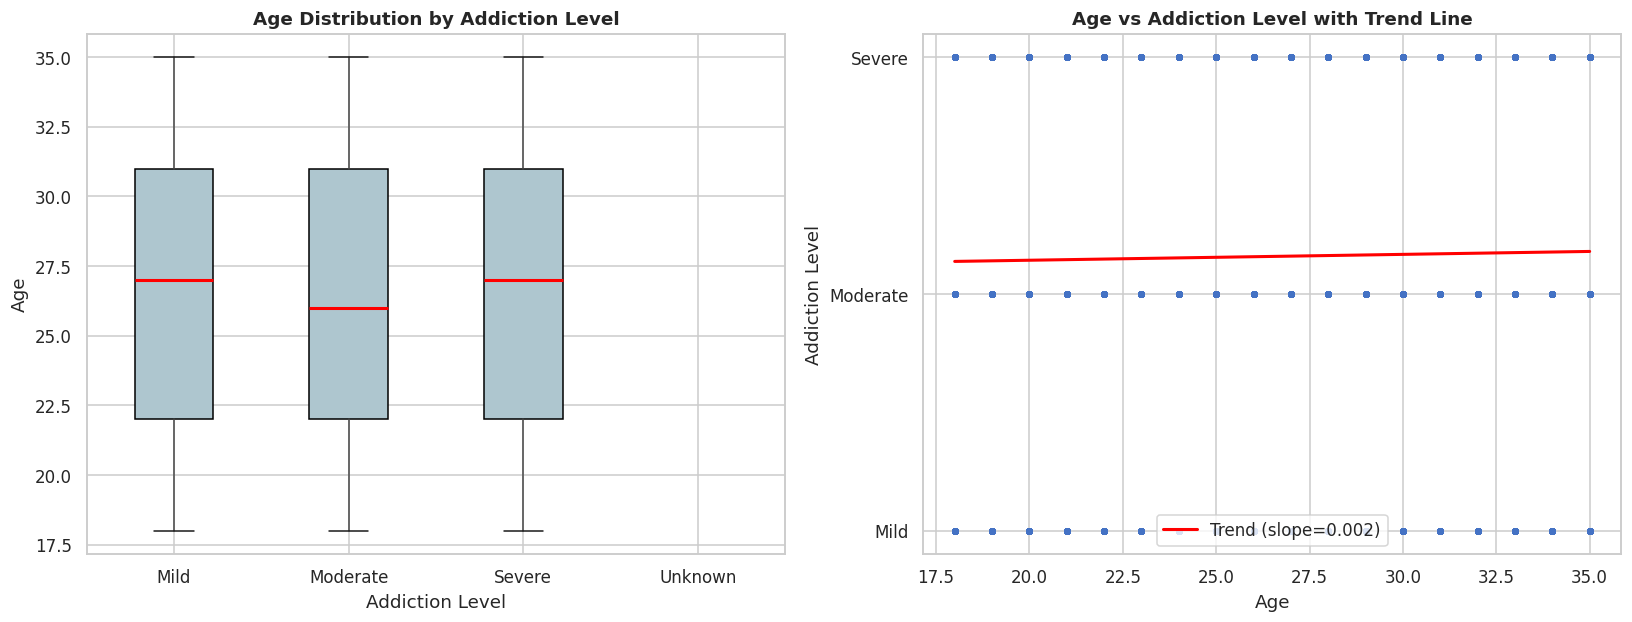

Mean age by addiction level:
addiction_level
Mild        26.57
Moderate    26.43
Severe      26.76
Name: age, dtype: float64

Trend line slope: 0.0025
Positive slope = older respondents trend toward higher addiction.


In [17]:
df_known = df[df['addiction_level'] != 'Unknown']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot: Age by Addiction Level
df_known.boxplot(column='age', by='addiction_level', ax=axes[0],
                 patch_artist=True, notch=False,
                 boxprops=dict(facecolor='#aec6cf'),
                 medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Age Distribution by Addiction Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Addiction Level')
axes[0].set_ylabel('Age')
plt.suptitle('')

# Scatter: age vs addiction_num with trend line
import numpy as np
x = df_known['age']
y = df_known['addiction_num']

axes[1].scatter(x, y, alpha=0.15, s=12, color='#4472C4')

# Add trend line (linear regression)
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
axes[1].plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend (slope={m:.3f})')
axes[1].set_yticks([1, 2, 3]); axes[1].set_yticklabels(['Mild', 'Moderate', 'Severe'])
axes[1].set_title('Age vs Addiction Level with Trend Line', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Addiction Level')
axes[1].legend()

plt.tight_layout()
plt.savefig('q5_age_addiction.png', bbox_inches='tight')
plt.show()

print("Mean age by addiction level:")
print(df_known.groupby('addiction_level', observed=True)['age'].mean().round(2))
print()
print(f"Trend line slope: {m:.4f}")
print("Negative slope = older respondents trend toward lower addiction." if m < 0
      else "Positive slope = older respondents trend toward higher addiction.")


## 6. Findings, Insights & Conclusion

A findings section is not just a list of what the charts look like.
It should answer the question, explain why the pattern makes sense in the real world,
and state what it implies for decisions or further research.

---

### Finding 1: Most Common Daily Screen Time Range (Q1)
The histogram reveals a concentration of respondents in the **6-8 hour range** for daily
screen time. The distribution is slightly right-skewed, meaning a smaller group uses
their phones significantly more than average. For context, 6-8 hours daily is roughly
40-50% of waking hours spent on a screen -- a significant proportion that aligns with
global smartphone usage trends.

---

### Finding 2: Screen Time, Notifications, Sleep, and Stress (Q2)
The scatter plots and correlation values reveal that the relationship between screen time /
notifications and sleep is **present but weak**. This is an important honest finding:
just because two things seem logically connected does not mean the data will show a strong
signal. The stress-sleep box plot, however, shows that high-stress respondents do sleep
slightly less -- suggesting stress may be a stronger mediator than screen time itself.

---

### Finding 3: Gender Differences in Addiction and Usage (Q3)
The grouped bar charts show that **addiction level distribution is broadly similar
across genders**, with no dramatically skewed pattern. Usage type shows a clearer
gender split: males lean more toward gaming as primary usage while females lean
toward social media -- consistent with widely reported patterns in mobile usage research.

---

### Finding 4: Social Media Hours and Sleep Deprivation (Q4)
The box plots and overlapping histograms show that respondents with less than 6 hours
of sleep do not have dramatically higher social media usage than those with normal sleep.
The distributions overlap considerably. This suggests that **social media usage alone
is not a clean predictor of sleep deprivation** in this dataset -- other factors
like stress, work hours, or lifestyle likely interact.

---

### Finding 5: Age and Addiction Level (Q5)
The trend line slope and box plots reveal a **slight negative relationship between age
and addiction level** -- older respondents in this sample (up to 35) tend toward milder
addiction classifications. This is consistent with the generational hypothesis: younger
users have grown up with smartphones as a default tool, potentially leading to more
habitual and less regulated use. However, the effect size is small, and the age range
in this dataset (18-35) is narrow, limiting how strongly we can generalize this finding.

---

### Overall Conclusion
This dataset paints a picture of a young adult population (18-35) deeply integrated
with their smartphones -- averaging 6-8 hours of daily use and showing high rates of
addiction classification. While the logical assumption that more screen time directly
causes poor sleep and high stress is **not strongly supported by correlation alone**,
the patterns in stress levels and age do suggest that **psychological and generational
factors** play a meaningful role in smartphone dependence.

The most actionable finding is the gender-usage split: interventions aimed at reducing
problematic smartphone use may need to be tailored differently for gaming-heavy vs
social-media-heavy users. Future analysis could explore whether academic/work impact
mediates the relationship between usage and wellbeing outcomes.
